In [3]:
# ====== CONFIG ======
import os
import math
import copy
from pathlib import Path
from typing import Tuple, List, Dict

import numpy as np
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms, datasets, models

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# =========================
# 1) Paths & hyperparams
# =========================
DATASET_DIR = r"C:\Users\HP\Downloads\Dataset"

IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 3
NUM_WORKERS = 2
LR = 1e-4
WEIGHT_DECAY = 1e-4
N_SPLITS = 3  # we will label folds as 3,4,5 below

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# =========================
# 2) Preprocessing Blocks
# =========================
# PST 
def pst_like(img_bgr: np.ndarray) -> np.ndarray:
    # Ensure 8-bit BGR
    if img_bgr.dtype != np.uint8:
        img_bgr = (np.clip(img_bgr, 0, 1) * 255).astype(np.uint8)

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = cv2.magnitude(gx, gy)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # stack edges as detail layer with original
    edge_3ch = cv2.merge([mag, mag, mag])

    # Unsharp mask to enhance edges
    blurred = cv2.GaussianBlur(img_bgr, (0, 0), 1.0)
    sharp = cv2.addWeighted(img_bgr, 1.5, blurred, -0.5, 0)

    # Blend edge map and sharpened image
    pst_img = cv2.addWeighted(sharp, 0.7, edge_3ch, 0.3, 0)
    return pst_img

# QHED 
def qhed_like(img_bgr: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    L_eq = clahe.apply(L)
    lab_eq = cv2.merge([L_eq, A, B])
    out_bgr = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)
    return out_bgr

# Compose pipeline per case
def preprocess_case(case: str, img_bgr: np.ndarray) -> np.ndarray:
    out = img_bgr
    if case in ["PST", "Raw+PST", "PST+QHED", "Raw+PST+QHED"]:
        out = pst_like(out)
    if case in ["QHED", "Raw+QHED", "PST+QHED", "Raw+PST+QHED"]:
        out = qhed_like(out)
    # Raw means do nothing special here (basic resize/normalize later)
    return out

# Torch transform after preprocessing
def get_post_transforms(image_size: int = IMAGE_SIZE):
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],  # ImageNet mean
            std=[0.229, 0.224, 0.225],
        ),
    ])

# ==========================================
# 3) Dataset wrapper with preprocessing case
# ==========================================
class PreprocessedImageFolder(Dataset):
    def __init__(self, base_ds: datasets.ImageFolder, case: str, post_tfms=None):
        self.base_ds = base_ds
        self.case = case
        self.post_tfms = post_tfms or get_post_transforms()

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        path, label = self.base_ds.samples[idx]
        # Read as BGR for OpenCV ops
        bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if bgr is None:
            raise RuntimeError(f"Failed to read image: {path}")
        bgr = preprocess_case(self.case, bgr)
        img = self.post_tfms(bgr)
        return img, label

# =========================
# 4) Models
# =========================
class ECNN(nn.Module):
    """A small efficient CNN for baseline."""
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

def build_vit(num_classes: int):
    # torchvision ViT (weights optional)
    vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    # Replace head
    vit.heads.head = nn.Linear(vit.heads.head.in_features, num_classes)
    return vit

# Late-fusion wrapper (average logits)
class FusionModel(nn.Module):
    def __init__(self, model_a: nn.Module, model_b: nn.Module):
        super().__init__()
        self.model_a = model_a
        self.model_b = model_b

    def forward(self, x):
        logits_a = self.model_a(x)
        logits_b = self.model_b(x)
        return 0.5 * logits_a + 0.5 * logits_b

# =========================
# 5) Training / Eval
# =========================
def train_one_epoch(model, loader, optim, criterion, device):
    model.train()
    all_preds, all_labels = [], []
    running_loss = 0.0
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optim.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optim.step()

        running_loss += loss.item() * imgs.size(0)

        preds = logits.argmax(1)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return avg_loss, acc, prec, rec, f1

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    all_preds, all_labels = [], []
    running_loss = 0.0
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)

        preds = logits.argmax(1)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return avg_loss, acc, prec, rec, f1

def print_metrics_block(header: str, history: List[Dict[str, float]]):
    print(header)
    print("Epoch  Accuracy  Precision  Recall  F1")
    for e, m in enumerate(history, 1):
        print(f"{e:>5}  {m['acc']:.4f}    {m['prec']:.4f}    {m['rec']:.4f}  {m['f1']:.4f}")

# =========================
# 6) Cross-validation run
# =========================
def run_experiment():
    # Base dataset 
    base = datasets.ImageFolder(DATASET_DIR)
    num_classes = len(base.classes)
    labels = np.array([y for _, y in base.samples])

    preproc_cases = [
        "Raw",
        "PST",
        "QHED",
        "Raw+PST",
        "Raw+QHED",
        "PST+QHED",
        "Raw+PST+QHED",
    ]

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    # We’ll label folds as 3, 4, 5 (to match your prior structure)
    fold_labels = [3, 4, 5]

    for case in preproc_cases:
        # Create a view of dataset with the chosen preprocessing
        ds_case = PreprocessedImageFolder(base, case, post_tfms=get_post_transforms())

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
            fold_id = fold_labels[fold_idx]
            train_ds = Subset(ds_case, train_idx.tolist())
            val_ds   = Subset(ds_case, val_idx.tolist())

            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
            val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

            # ========== Models ==========
            # ECNN
            ecnn = ECNN(num_classes).to(DEVICE)
            # ViT
            vit = build_vit(num_classes).to(DEVICE)
            # Fusion
            fusion = FusionModel(copy.deepcopy(vit), copy.deepcopy(ecnn)).to(DEVICE)

            for model_name, net in [
                ("ECNN", ecnn),
                ("ViT", vit),
                ("ViT+ECNN", fusion),
            ]:
                criterion = nn.CrossEntropyLoss()
                optimizer = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

                # ---- Training loop for NUM_EPOCHS with per-epoch metrics on VAL ----
                metrics_history = []
                print("=" * 90)
                print(f"Model: {model_name} | Preprocessing: {case} | Fold: {fold_id}")
                for epoch in range(1, NUM_EPOCHS + 1):
                    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
                        net, train_loader, optimizer, criterion, DEVICE
                    )
                    val_loss, val_acc, val_prec, val_rec, val_f1 = eval_one_epoch(
                        net, val_loader, criterion, DEVICE
                    )
                    metrics_history.append({
                        "acc": val_acc, "prec": val_prec, "rec": val_rec, "f1": val_f1
                    })
                    print(f"Epoch {epoch:>2d} | "
                          f"TrainLoss {train_loss:.4f} | ValLoss {val_loss:.4f} | "
                          f"Val Acc {val_acc:.4f} | P {val_prec:.4f} | R {val_rec:.4f} | F1 {val_f1:.4f}")

                # Final formatted block (as requested structure)
                print_metrics_block("---- Validation Metrics by Epoch ----", metrics_history)
                print("=" * 90 + "\n")

if __name__ == "__main__":
    assert os.path.isdir(DATASET_DIR), f"DATASET_DIR: {DATASET_DIR}"
    print(f"Using device: {DEVICE}")
    run_experiment()


Model: ECNN | Preprocessing: PST | Fold: 3
Model Preprocessing  Fold  Epoch  Accuracy  Precision  Recall     F1
 ECNN           PST     3      1    0.8710     0.8662  0.8734 0.8698
 ECNN           PST     3      2    0.8844     0.8816  0.8765 0.8791
 ECNN           PST     3      3    0.8848     0.8855  0.8846 0.8851

Model: ECNN | Preprocessing: PST | Fold: 4
Model Preprocessing  Fold  Epoch  Accuracy  Precision  Recall     F1
 ECNN           PST     4      1    0.8799     0.8867  0.8713 0.8789
 ECNN           PST     4      2    0.8732     0.8720  0.8696 0.8708
 ECNN           PST     4      3    0.8743     0.8786  0.8786 0.8786

Model: ECNN | Preprocessing: PST | Fold: 5
Model Preprocessing  Fold  Epoch  Accuracy  Precision  Recall     F1
 ECNN           PST     5      1    0.8649     0.8636  0.8589 0.8612
 ECNN           PST     5      2    0.8755     0.8788  0.8766 0.8777
 ECNN           PST     5      3    0.8822     0.8780  0.8819 0.8799

Model: ECNN | Preprocessing: PST+QHED | 

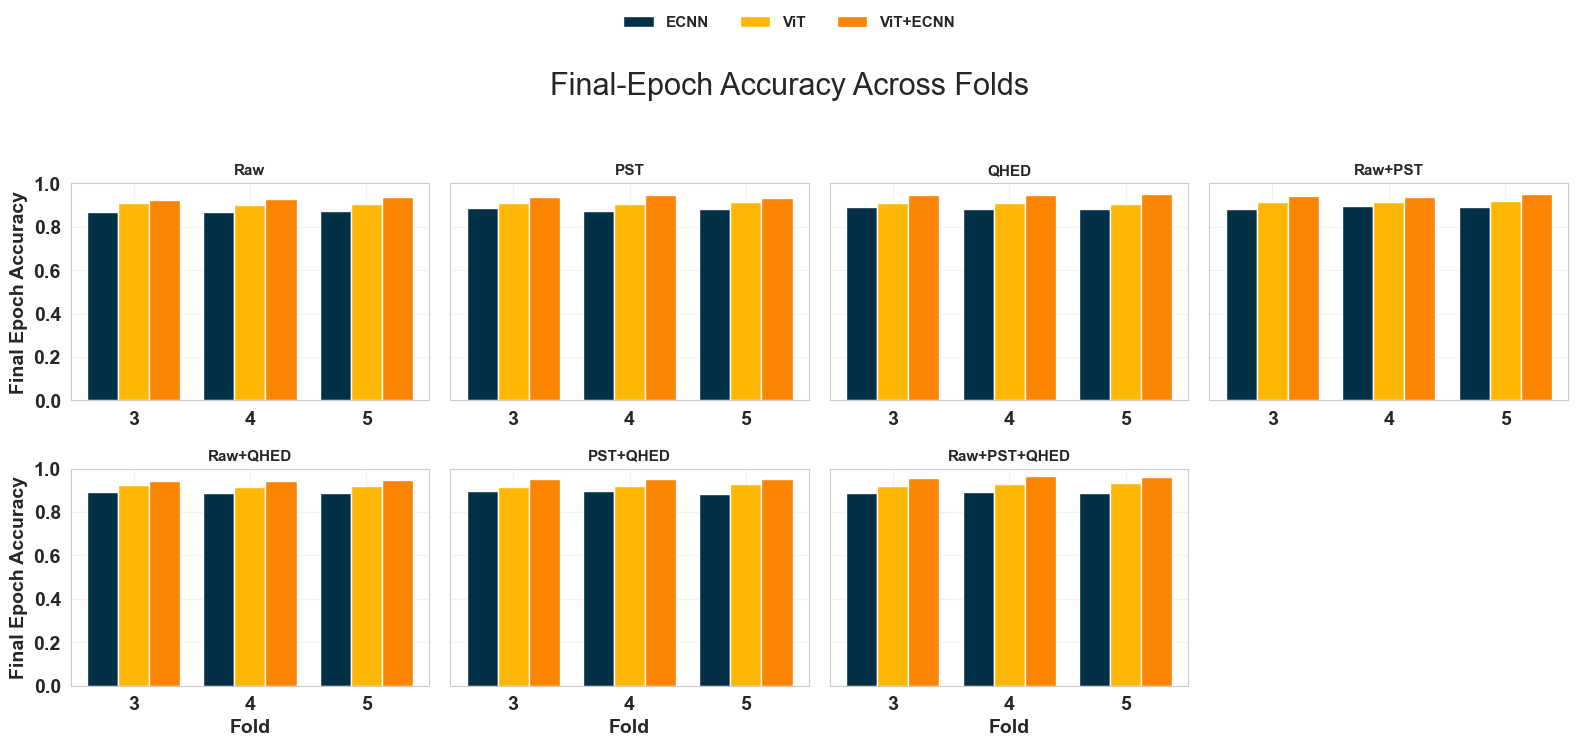

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import ceil
import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
sns.set_style("whitegrid")
# Assumes df exists with columns: Model, Preprocessing, Fold, Epoch, Accuracy, Precision, Recall, F1
final_df = df[df["Epoch"] == 3].copy()

# Fixed ordering to keep plots consistent
models = ["ECNN", "ViT", "ViT+ECNN"]
folds  = [3, 4, 5]
cases  = [
    "Raw", "PST", "QHED",
    "Raw+PST", "Raw+QHED",
    "PST+QHED", "Raw+PST+QHED"
]

# Color palette per model (as requested)
color_map = {
    "ECNN":    "#023047",
    "ViT":     "#ffb703",
    "ViT+ECNN":"#fb8500",
}

# Layout: 7 subplots (no stability chart)
n_cases = len(cases)
ncols = 4
nrows = ceil(n_cases / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows), sharey=True)
axes = np.atleast_2d(axes)

def grouped_bars(ax, case_df: pd.DataFrame, case_name: str):
    """
    Bars for each model (colored by model) grouped within each fold.
    X-axis categories = folds [3,4,5]
    """
    x = np.arange(len(folds))                  # positions for folds
    width = 0.8 / len(models)                  # group width split among 3 models

    for i, model in enumerate(models):
        sub = (case_df[case_df["Model"] == model]
               .set_index("Fold")
               .reindex(folds))
        acc = sub["Accuracy"].values.astype(float)
        ax.bar(
            x + i*width - (len(models)-1)*width/2,
            acc, width=width,
            label=model if case_name == cases[0] else None,  # legend from first subplot
            color=color_map[model]
        )

    ax.set_xticks(x)
    ax.set_xticklabels([str(f) for f in folds])
    ax.set_ylim(0.0, 1.0)
    ax.set_title(case_name, fontsize=11)
    ax.grid(True, alpha=0.25)

# Plot each preprocessing case
for idx, case in enumerate(cases):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]
    case_df = final_df[final_df["Preprocessing"] == case]
    grouped_bars(ax, case_df, case)
    if r == nrows - 1:
        ax.set_xlabel("Fold")
    if c == 0:
        ax.set_ylabel("Final Epoch Accuracy")

# Hide unused axes (e.g., slot 8 in a 2x4 grid)
for j in range(n_cases, nrows * ncols):
    rr, cc = divmod(j, ncols)
    fig.delaxes(axes[rr, cc])

# Shared legend ABOVE plots with extra spacing from title
# (handles from the first axes that had labels)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=len(models),
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 1.08)  # push legend further up to leave space
)

# Title placed a bit lower to add space from legend
fig.suptitle(
    "Final-Epoch Accuracy Across Folds",
    fontsize=22,
    y=0.98
)

# Leave space at the top for legend + title
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
